# Lab 4: KNN Classification on Breast Cancer Dataset

**Aim:** To implement KNN classification on the breast cancer dataset and analyse model performance using train-test split, heuristic K selection, cross-validation, ROC-AUC, and classification metrics. The notebook also compares classification metrics with regression metrics studied in Linear Regression (Lab 3).

## Task 1: Data Preparation

The local `brca.csv` file is used for this lab. It contains the Breast Cancer Wisconsin Diagnostic features and a target column `y` with values `B` and `M`.

In [ ]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
)
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load and inspect dataset
brca = pd.read_csv("brca.csv")

print("Dataset loaded from brca.csv")
print("The data has", brca.shape[0], "rows and", brca.shape[1], "columns.")
print("There are 30 measurement features, one target column y, and one index-like column.")
print("\nFirst five rows:")
display(brca.head())

print("\nTarget distribution before encoding:")
print(brca["y"].value_counts())

print("\nMissing values in the dataset:", int(brca.isna().sum().sum()))
print("Duplicate rows in the dataset:", int(brca.duplicated().sum()))

Dataset loaded from brca.csv
The data has 569 rows and 32 columns.
There are 30 measurement features, one target column y, and one index-like column.

First five rows:


,Unnamed: 0,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,...,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst,y
0,1,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.047810,0.1885,...,19.26,99.70,711.2,0.14400,0.17730,0.23900,0.12880,0.2977,0.07259,B
1,2,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.031100,0.1967,...,20.49,96.09,630.5,0.13120,0.27760,0.18900,0.07283,0.3184,0.08183,B
2,3,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,...,15.66,65.13,314.9,0.13240,0.11480,0.08867,0.06227,0.2450,0.07773,B
3,4,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.029230,0.1467,...,22.81,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169,B
4,5,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,0.1769,...,21.96,57.26,242.2,0.12970,0.13570,0.06880,0.02564,0.3105,0.07409,B



Target distribution before encoding:
y
B    357
M    212
Name: count, dtype: int64

Missing values in the dataset: 0
Duplicate rows in the dataset: 0


In [ ]:
# Prepare X and y
X = brca.drop(columns=["y", "Unnamed: 0"])

# For medical diagnosis, malignant is treated as the positive class.
y = brca["y"].map({"B": 0, "M": 1})

print("Target encoding used in this notebook:")
print("0 = Benign")
print("1 = Malignant / cancer positive")
print("\nThis positive-class choice is important because missing malignant cases is the highest-risk error.")
print("\nFeature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Target encoding used in this notebook:
0 = Benign
1 = Malignant / cancer positive

This positive-class choice is important because missing malignant cases is the highest-risk error.

Feature matrix shape: (569, 30)
Target vector shape: (569,)


In [4]:
# Feature scaling demonstration
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("KNN is distance-based, so feature scaling is required.")
print("Without scaling, large-range features like area can dominate small-range features like smoothness.")
print("After StandardScaler, each feature is centered near mean 0 and standard deviation 1.")
print("\nOriginal feature range examples:")
print(X[["x.area_mean", "x.smoothness_mean", "x.fractal_dim_mean"]].agg(["mean", "std", "min", "max"]))
print("\nScaled feature summary for the same columns:")
print(X_scaled_df[["x.area_mean", "x.smoothness_mean", "x.fractal_dim_mean"]].agg(["mean", "std", "min", "max"]).round(3))

KNN is distance-based, so feature scaling is required.
Without scaling, large-range features like area can dominate small-range features like smoothness.
After StandardScaler, each feature is centered near mean 0 and standard deviation 1.

Original feature range examples:
      x.area_mean  x.smoothness_mean  x.fractal_dim_mean
mean   654.889104           0.096360            0.062798
std    351.914129           0.014064            0.007060
min    143.500000           0.052630            0.049960
max   2501.000000           0.163400            0.097440

Scaled feature summary for the same columns:
      x.area_mean  x.smoothness_mean  x.fractal_dim_mean
mean       -0.000              0.000               0.000
std         1.001              1.001               1.001
min        -1.454             -3.112              -1.820
max         5.251              4.771               4.911


## Task 2: Train-Test Split Analysis

KNN is trained under three train-test split ratios. The same preprocessing and heuristic K rule are used for a fair comparison.

In [5]:
def make_odd(k):
    """Return an odd K so ties are less likely in binary classification."""
    k = int(round(k))
    return k if k % 2 == 1 else k + 1

split_results = []
splits = [(0.20, "80:20"), (0.30, "70:30"), (0.10, "90:10")]

for test_size, label in splits:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )
    heuristic_k = make_odd(np.sqrt(len(X_train)))
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=heuristic_k)),
    ])
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    split_results.append({
        "Split": label,
        "Train rows": len(X_train),
        "Test rows": len(X_test),
        "Heuristic K": heuristic_k,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
    })

split_results_df = pd.DataFrame(split_results)
display(split_results_df.round(4))

print("The split comparison shows how performance changes when the amount of test data changes.")
print("A 90:10 split trains on more data but tests on fewer cases, so the estimate can be less stable.")
print("A 70:30 split tests on more cases but leaves less training data for the model.")
print("The 80:20 split is used as the main split because it balances training data and test reliability.")

,Split,Train rows,Test rows,Heuristic K,Accuracy,Precision,Recall,F1 Score
0,80:20,455,114,21,0.9386,0.973,0.8571,0.9114
1,70:30,398,171,21,0.9532,1.000,0.8750,0.9333
2,90:10,512,57,23,0.9474,0.950,0.9048,0.9268


The split comparison shows how performance changes when the amount of test data changes.
A 90:10 split trains on more data but tests on fewer cases, so the estimate can be less stable.
A 70:30 split tests on more cases but leaves less training data for the model.
The 80:20 split is used as the main split because it balances training data and test reliability.


## Task 3: KNN Model with Heuristic K Selection

The heuristic rule is `K = sqrt(n)`, where `n` is the number of training samples. Nearby K values are then tested to see whether validation performance improves.

In [6]:
# Main 80:20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

heuristic_k = make_odd(np.sqrt(len(X_train)))
print("Training rows:", len(X_train))
print("sqrt(n) =", round(np.sqrt(len(X_train)), 2))
print("Baseline heuristic K selected:", heuristic_k)
print("An odd K is preferred to reduce tied votes in binary classification.")

Training rows: 455
sqrt(n) = 21.33
Baseline heuristic K selected: 21
An odd K is preferred to reduce tied votes in binary classification.


,K,Accuracy,Recall,F1 Score
0,16,0.9386,0.8571,0.9114
1,17,0.9386,0.8571,0.9114
2,18,0.9386,0.8571,0.9114
3,19,0.9386,0.8571,0.9114
4,20,0.9386,0.8571,0.9114
5,21,0.9386,0.8571,0.9114
6,22,0.9386,0.8571,0.9114
7,23,0.9386,0.8571,0.9114
8,24,0.9474,0.8571,0.9231
9,25,0.9474,0.8571,0.9231


Best nearby K based on test F1, recall, then accuracy: 24
For medical diagnosis, recall is watched carefully because a false negative means a malignant case was missed.


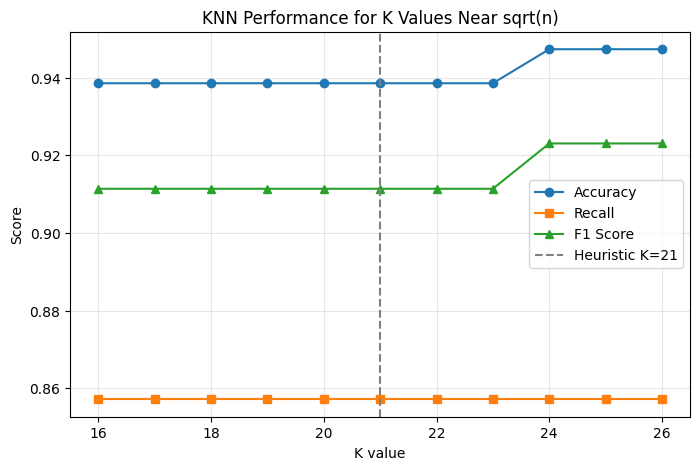

In [7]:
# Test nearby K values around the heuristic K
k_values = list(range(max(1, heuristic_k - 5), heuristic_k + 6))
k_results = []

for k in k_values:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k)),
    ])
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    k_results.append({
        "K": k,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
    })

k_results_df = pd.DataFrame(k_results)
display(k_results_df.round(4))

best_test_k = int(k_results_df.sort_values(["F1 Score", "Recall", "Accuracy"], ascending=False).iloc[0]["K"])
print("Best nearby K based on test F1, recall, then accuracy:", best_test_k)
print("For medical diagnosis, recall is watched carefully because a false negative means a malignant case was missed.")

plt.figure(figsize=(8, 5))
plt.plot(k_results_df["K"], k_results_df["Accuracy"], marker="o", label="Accuracy")
plt.plot(k_results_df["K"], k_results_df["Recall"], marker="s", label="Recall")
plt.plot(k_results_df["K"], k_results_df["F1 Score"], marker="^", label="F1 Score")
plt.axvline(heuristic_k, color="gray", linestyle="--", label=f"Heuristic K={heuristic_k}")
plt.xlabel("K value")
plt.ylabel("Score")
plt.title("KNN Performance for K Values Near sqrt(n)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Distance Metrics and Decision Boundary Mapping

In [8]:
print("Euclidean distance measures straight-line distance between two points.")
print("It is suitable when features are continuous, scaled, and geometric closeness is meaningful.")
print("\nManhattan distance sums absolute coordinate differences.")
print("It is useful when movement is grid-like or when absolute feature-wise differences are preferred.")
print("\nFor this 30-feature dataset, decision boundaries cannot be plotted directly in 30D.")
print("Therefore, PCA is used to compress the scaled features into two components only for visualization.")
print("The actual model evaluation still uses all original 30 features.")

Euclidean distance measures straight-line distance between two points.
It is suitable when features are continuous, scaled, and geometric closeness is meaningful.

Manhattan distance sums absolute coordinate differences.
It is useful when movement is grid-like or when absolute feature-wise differences are preferred.

For this 30-feature dataset, decision boundaries cannot be plotted directly in 30D.
Therefore, PCA is used to compress the scaled features into two components only for visualization.
The actual model evaluation still uses all original 30 features.


PCA component variance explained:
PC1: 0.443
PC2: 0.19
The plot is a 2D approximation used only to understand how K changes boundary smoothness.


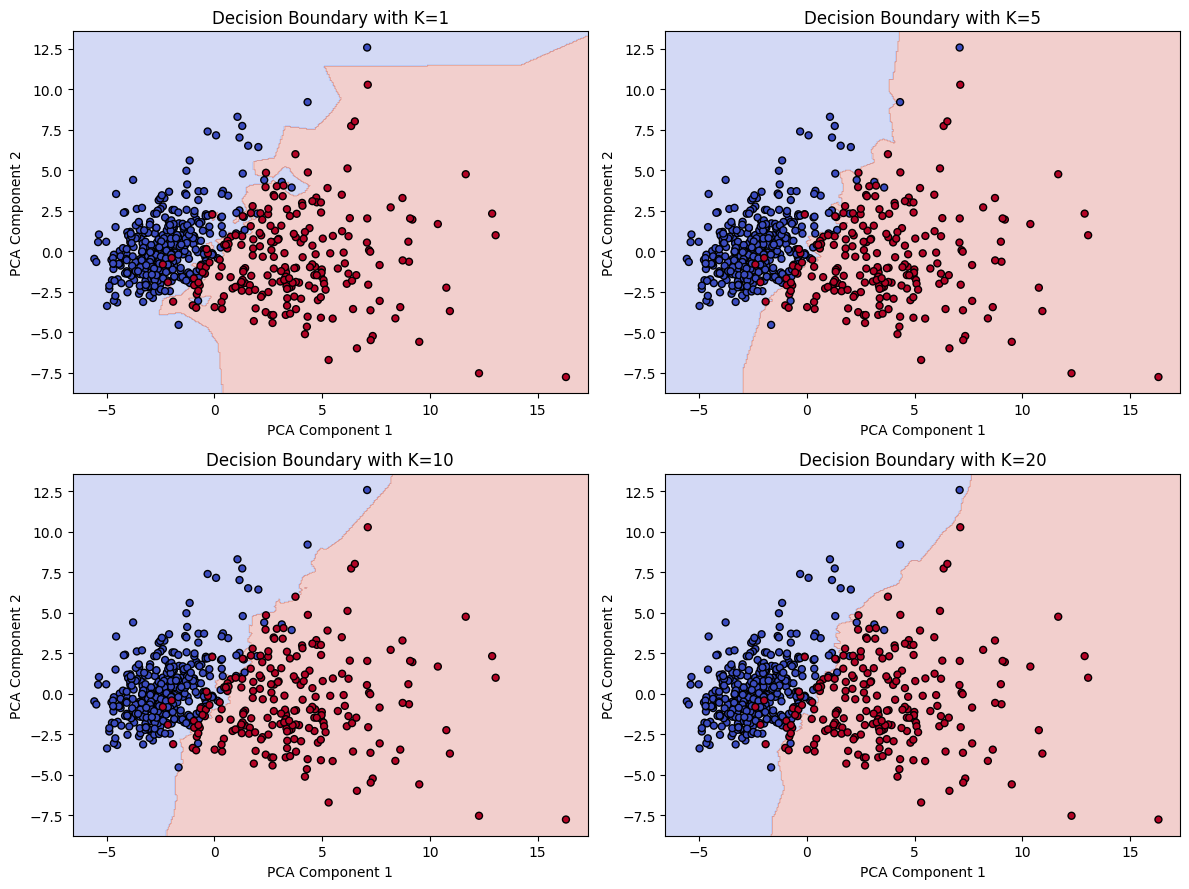

As K increases, the boundary becomes smoother and less sensitive to individual noisy points.
K=1 gives a very flexible boundary with high variance, while larger K values increase bias.


In [9]:
# Decision boundary visualization using PCA-reduced 2D features
X_scaled_all = StandardScaler().fit_transform(X)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled_all)

print("PCA component variance explained:")
print("PC1:", round(pca.explained_variance_ratio_[0], 3))
print("PC2:", round(pca.explained_variance_ratio_[1], 3))
print("The plot is a 2D approximation used only to understand how K changes boundary smoothness.")

x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 350), np.linspace(y_min, y_max, 350))

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, k in zip(axes.ravel(), [1, 5, 10, 20]):
    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(X_pca, y)
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap="coolwarm")
    scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap="coolwarm", edgecolor="k", s=25)
    ax.set_title(f"Decision Boundary with K={k}")
    ax.set_xlabel("PCA Component 1")
    ax.set_ylabel("PCA Component 2")

plt.tight_layout()
plt.show()

print("As K increases, the boundary becomes smoother and less sensitive to individual noisy points.")
print("K=1 gives a very flexible boundary with high variance, while larger K values increase bias.")

## Task 4: Cross Validation

Cross-validation evaluates K over multiple training-validation folds, making the result more reliable than depending on one train-test split.

,K,Mean CV Accuracy,Std CV Accuracy
0,1,0.9525,0.0193
1,3,0.9667,0.0228
2,5,0.9667,0.0277
3,7,0.9632,0.0288
4,9,0.9702,0.0249
5,11,0.9684,0.0258
6,13,0.9684,0.0219
7,15,0.9649,0.0222
8,17,0.9614,0.0232
9,19,0.9596,0.0193


Best K from 10-fold cross-validation: 9
Heuristic K was 21 so final selection considers both sqrt(n) and validation performance.


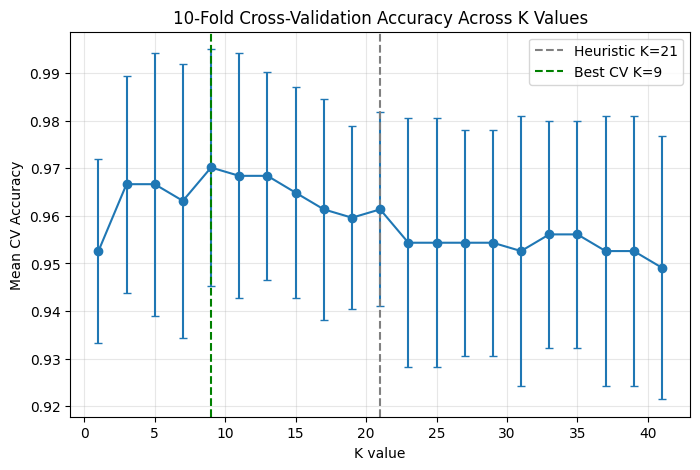

Cross-validation is more reliable because every observation gets used for validation once.
This reduces dependence on one lucky or unlucky train-test split.


In [10]:
# Cross-validation for different K values
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_k_values = list(range(1, 42, 2))
cv_results = []

for k in cv_k_values:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k)),
    ])
    scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")
    cv_results.append({
        "K": k,
        "Mean CV Accuracy": scores.mean(),
        "Std CV Accuracy": scores.std(),
    })

cv_results_df = pd.DataFrame(cv_results)
display(cv_results_df.round(4))

best_cv_k = int(cv_results_df.sort_values("Mean CV Accuracy", ascending=False).iloc[0]["K"])
print("Best K from 10-fold cross-validation:", best_cv_k)
print("Heuristic K was", heuristic_k, "so final selection considers both sqrt(n) and validation performance.")

plt.figure(figsize=(8, 5))
plt.errorbar(
    cv_results_df["K"],
    cv_results_df["Mean CV Accuracy"],
    yerr=cv_results_df["Std CV Accuracy"],
    marker="o",
    capsize=3,
)
plt.axvline(heuristic_k, color="gray", linestyle="--", label=f"Heuristic K={heuristic_k}")
plt.axvline(best_cv_k, color="green", linestyle="--", label=f"Best CV K={best_cv_k}")
plt.xlabel("K value")
plt.ylabel("Mean CV Accuracy")
plt.title("10-Fold Cross-Validation Accuracy Across K Values")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("Cross-validation is more reliable because every observation gets used for validation once.")
print("This reduces dependence on one lucky or unlucky train-test split.")

## Task 5: Classification Evaluation

The final model is evaluated using classification metrics, confusion matrix, ROC curve, and AUC score.

In [11]:
# Final model using best cross-validated K
final_k = best_cv_k
final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=final_k)),
])

final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print("Final KNN model evaluation on the 80:20 test set")
print("Final K:", final_k)
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))
print("ROC-AUC  :", round(auc, 4))
print("\nClassification report where 1 means malignant:")
print(classification_report(y_test, y_pred, target_names=["Benign", "Malignant"]))

print("Accuracy gives overall correctness, but recall tells how many malignant cases were detected.")
print("ROC-AUC summarizes how well the model separates malignant and benign cases across thresholds.")

Final KNN model evaluation on the 80:20 test set
Final K: 9
Accuracy : 0.9474
Precision: 0.9737
Recall   : 0.881
F1 Score : 0.925
ROC-AUC  : 0.9812

Classification report where 1 means malignant:
              precision    recall  f1-score   support

      Benign       0.93      0.99      0.96        72
   Malignant       0.97      0.88      0.93        42

    accuracy                           0.95       114
   macro avg       0.95      0.93      0.94       114
weighted avg       0.95      0.95      0.95       114

Accuracy gives overall correctness, but recall tells how many malignant cases were detected.
ROC-AUC summarizes how well the model separates malignant and benign cases across thresholds.


,Predicted Benign,Predicted Malignant
Actual Benign,71,1
Actual Malignant,5,37


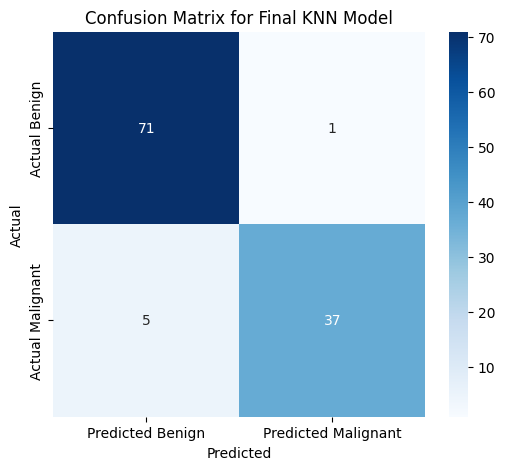

True Negatives  : 71 benign cases correctly predicted as benign
False Positives : 1 benign cases predicted as malignant
False Negatives : 5 malignant cases predicted as benign
True Positives  : 37 malignant cases correctly predicted as malignant
In cancer prediction, false negatives are especially serious because the disease may be missed.


In [12]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=["Actual Benign", "Actual Malignant"],
    columns=["Predicted Benign", "Predicted Malignant"],
)

display(cm_df)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix for Final KNN Model")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

tn, fp, fn, tp = cm.ravel()
print("True Negatives  :", tn, "benign cases correctly predicted as benign")
print("False Positives :", fp, "benign cases predicted as malignant")
print("False Negatives :", fn, "malignant cases predicted as benign")
print("True Positives  :", tp, "malignant cases correctly predicted as malignant")
print("In cancer prediction, false negatives are especially serious because the disease may be missed.")

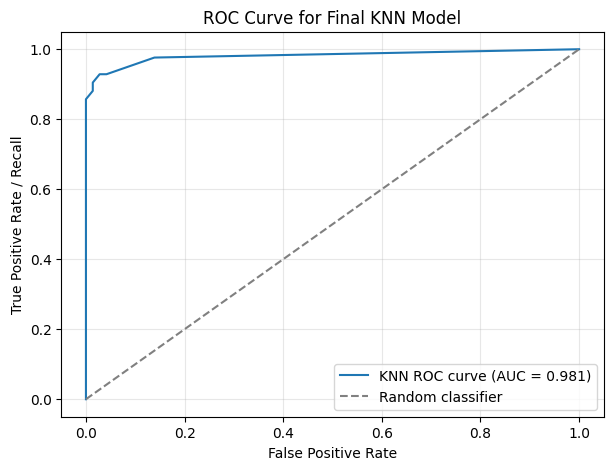

The ROC curve shows the trade-off between detecting malignant cases and raising false alarms.
A higher AUC means the classifier ranks malignant cases above benign cases more consistently.


In [13]:
# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"KNN ROC curve (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Recall")
plt.title("ROC Curve for Final KNN Model")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("The ROC curve shows the trade-off between detecting malignant cases and raising false alarms.")
print("A higher AUC means the classifier ranks malignant cases above benign cases more consistently.")

## Task 6: Comparative Study with Regression Metrics from Lab 3

Lab 3 used regression metrics such as MAE, MSE, RMSE, and R2 Score. Those metrics are designed for continuous targets. In this lab, the target is categorical, so classification metrics are required.

In [14]:
comparison = pd.DataFrame({
    "Regression Metric": ["MAE", "MSE", "RMSE", "R2 Score"],
    "What it measures": [
        "Average absolute prediction error",
        "Average squared prediction error",
        "Typical error size in target units",
        "Proportion of target variance explained",
    ],
    "Classification comparison": [
        "Confusion matrix counts different decision outcomes",
        "No direct equivalent; classification loss depends on wrong decisions",
        "F1 Score balances precision and recall instead of measuring numeric distance",
        "Accuracy measures proportion of correct class decisions",
    ],
})

display(comparison)

print("Regression evaluation is error-based because predictions are continuous numbers.")
print("Classification evaluation is decision-based because predictions are class labels or class probabilities.")
print("R2 and accuracy are not the same: R2 measures explained variance, while accuracy measures correct labels.")
print("RMSE and F1 are not the same: RMSE measures error magnitude, while F1 balances false positives and false negatives.")
print("MAE and confusion matrix are not the same: MAE averages numeric error, while confusion matrix shows decision types.")

,Regression Metric,What it measures,Classification comparison
0,MAE,Average absolute prediction error,Confusion matrix counts different decision out...
1,MSE,Average squared prediction error,No direct equivalent; classification loss depe...
2,RMSE,Typical error size in target units,F1 Score balances precision and recall instead...
3,R2 Score,Proportion of target variance explained,Accuracy measures proportion of correct class ...


Regression evaluation is error-based because predictions are continuous numbers.
Classification evaluation is decision-based because predictions are class labels or class probabilities.
R2 and accuracy are not the same: R2 measures explained variance, while accuracy measures correct labels.
RMSE and F1 are not the same: RMSE measures error magnitude, while F1 balances false positives and false negatives.
MAE and confusion matrix are not the same: MAE averages numeric error, while confusion matrix shows decision types.


In [15]:
print("Inference:")
print("Regression metrics measure how far predicted values are from actual continuous values.")
print("Classification metrics measure whether the model made the correct class decision.")
print("Accuracy is insufficient in medical diagnosis because a model can look accurate while still missing serious malignant cases.")
print("Recall is more relevant in healthcare because it measures how many actual malignant cases are detected.")
print("ROC-AUC is useful because it evaluates class separation across different decision thresholds.")
print("Overall, regression evaluation focuses on prediction error magnitude, while classification evaluation focuses on correctness, error types, and decision risk.")

Inference:
Regression metrics measure how far predicted values are from actual continuous values.
Classification metrics measure whether the model made the correct class decision.
Accuracy is insufficient in medical diagnosis because a model can look accurate while still missing serious malignant cases.
Recall is more relevant in healthcare because it measures how many actual malignant cases are detected.
ROC-AUC is useful because it evaluates class separation across different decision thresholds.
Overall, regression evaluation focuses on prediction error magnitude, while classification evaluation focuses on correctness, error types, and decision risk.


## Task 7: Analytical Questions

In [16]:
print("1. Why is KNN called a lazy learning algorithm?")
print("KNN is lazy because it does not learn a fixed equation during training. It stores the training data and makes decisions only when a new point is queried.")

print("\n2. Why is feature scaling required in KNN?")
print("KNN uses distance. If features are on different scales, large numeric features dominate the distance calculation.")

print("\n3. Explain heuristic K selection using sqrt(n) rule.")
print("The sqrt(n) rule selects K near the square root of the training sample size. It gives a simple starting point before validation-based tuning.")

print("\n4. Why is cross-validation more reliable than a single train-test split?")
print("Cross-validation tests the model across multiple folds, so performance is less dependent on one random split.")

print("\n5. How does K affect the bias-variance trade-off?")
print("Small K has low bias and high variance. Large K has higher bias and lower variance because predictions become smoother.")

print("\n6. Why is recall more important than accuracy in cancer prediction?")
print("Recall focuses on detecting actual malignant cases. Missing a malignant case is usually more harmful than a false alarm.")

print("\n7. What is the limitation of very large K values?")
print("Very large K values over-smooth the decision boundary and may ignore local patterns, causing underfitting.")

1. Why is KNN called a lazy learning algorithm?
KNN is lazy because it does not learn a fixed equation during training. It stores the training data and makes decisions only when a new point is queried.

2. Why is feature scaling required in KNN?
KNN uses distance. If features are on different scales, large numeric features dominate the distance calculation.

3. Explain heuristic K selection using sqrt(n) rule.
The sqrt(n) rule selects K near the square root of the training sample size. It gives a simple starting point before validation-based tuning.

4. Why is cross-validation more reliable than a single train-test split?
Cross-validation tests the model across multiple folds, so performance is less dependent on one random split.

5. How does K affect the bias-variance trade-off?
Small K has low bias and high variance. Large K has higher bias and lower variance because predictions become smoother.

6. Why is recall more important than accuracy in cancer prediction?
Recall focuses on de

## Conclusion

In [17]:
print("Conclusion:")
print("The heuristic sqrt(n) rule gave a baseline K of", heuristic_k, "for the 80:20 training set.")
print("Cross-validation selected K =", final_k, "as the final model value.")
print("Across different train-test splits, performance changed slightly because train and test sample sizes changed.")
print("The final KNN model achieved Accuracy =", round(accuracy, 4), ", Recall =", round(recall, 4), ", F1 =", round(f1, 4), ", and ROC-AUC =", round(auc, 4), ".")
print("For this healthcare classification task, recall and ROC-AUC are more informative than accuracy alone.")
print("Compared with Lab 3 regression, this lab evaluates class decisions instead of continuous prediction error.")

Conclusion:
The heuristic sqrt(n) rule gave a baseline K of 21 for the 80:20 training set.
Cross-validation selected K = 9 as the final model value.
Across different train-test splits, performance changed slightly because train and test sample sizes changed.
The final KNN model achieved Accuracy = 0.9474 , Recall = 0.881 , F1 = 0.925 , and ROC-AUC = 0.9812 .
For this healthcare classification task, recall and ROC-AUC are more informative than accuracy alone.
Compared with Lab 3 regression, this lab evaluates class decisions instead of continuous prediction error.
